# Step 6 — Similarity Scoring & Top-5 SDG Ranking
**Project:** SDG Mapping for PhD Thesis

**Purpose:** Directly map MAHE articles to SDGs using cosine similarity

**Outputs:** `data/results/mahe_top5_similarity.csv` · `data/results/mahe_top5_combined.csv`

> Track B — Direct similarity: embed MAHE articles + SDG profiles using GloVe → cosine similarity → softmax → Top-5 SDGs

In [1]:
# Cell 1: Install
!pip install pandas numpy scikit-learn matplotlib seaborn tqdm


In [2]:
# Cell 2: Imports
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from IPython.display import display
warnings.filterwarnings('ignore')

CLEAN_DIR   = Path('data/clean')
RESULTS_DIR = Path('data/results')
PLOT_DIR    = Path('data/plots')
GLOVE_FILE  = Path('data/glove/glove.6B.300d.txt')

with open('data/step2_meta.json') as f:
    meta = json.load(f)
SDG_NAMES = {int(k): v for k, v in meta['sdg_names'].items()}
print('Imports complete')


Imports complete


In [3]:
# Cell 3: SDG reference profiles
SDG_PROFILES = {
    1:  "End poverty all forms everywhere eradicate extreme poverty social protection poor vulnerable equal rights economic resources ownership property inheritance natural resources technology financial services reduce exposure vulnerability poor climate extreme events economic social environmental shocks disasters",
    2:  "End hunger achieve food security improved nutrition sustainable agriculture ensure access safe nutritious sufficient food malnutrition stunting wasting double agricultural productivity incomes smallholder food producers sustainable food production systems resilient agricultural practices biodiversity seeds genetic diversity crop livestock",
    3:  "Ensure healthy lives promote wellbeing all ages reduce maternal mortality neonatal mortality preventable deaths children end epidemics AIDS tuberculosis malaria neglected tropical diseases hepatitis water-borne infectious diseases achieve universal health coverage financial risk protection quality essential health care services medicines vaccines mental health substance abuse",
    4:  "Ensure inclusive equitable quality education promote lifelong learning free primary secondary education quality relevant learning outcomes equal access vocational training technical skills employment eliminate gender disparities persons with disabilities literacy numeracy skills youth adults teachers school infrastructure safe learning environments",
    5:  "Achieve gender equality empower all women girls end discrimination violence against women girls trafficking sexual exploitation equal participation leadership political economic public life universal access sexual reproductive health rights women empowerment technology ownership land rights",
    6:  "Ensure availability sustainable management water sanitation safe affordable drinking water adequate equitable sanitation hygiene end open defecation improve water quality reduce pollution wastewater treatment recycling safe reuse water use efficiency water scarcity freshwater supplies protect water related ecosystems rivers lakes aquifers wetlands",
    7:  "Ensure access affordable reliable sustainable modern energy electricity universal access clean cooking fuels technologies increase share renewable energy solar wind hydropower double global rate improvement energy efficiency buildings transport industry expand infrastructure upgrade technology energy services",
    8:  "Promote sustained inclusive sustainable economic growth full productive employment decent work sustain per capita economic growth GDP growth achieve higher productivity economic diversification technological upgrading innovation full employment equal pay men women youth eradicate forced labour modern slavery human trafficking child labour",
    9:  "Build resilient infrastructure promote inclusive sustainable industrialization foster innovation develop reliable sustainable resilient quality infrastructure regional transborder support economic development increase access financial services markets small scale industrial enterprises upgrade infrastructure retrofit industries sustainable clean technology research development innovation",
    10: "Reduce inequality within among countries achieve sustain income growth bottom population empower promote social economic political inclusion age sex disability race ethnicity origin religion economic status ensure equal opportunity reduce inequalities eliminate discriminatory laws policies fiscal wage social protection policies progressive migration remittances",
    11: "Make cities human settlements inclusive safe resilient sustainable ensure access adequate safe affordable housing basic services upgrade slums safe affordable accessible sustainable transport systems inclusive sustainable urbanization participatory integrated planning management protect cultural natural heritage reduce deaths disasters flood climate urban resilience air quality waste management",
    12: "Ensure sustainable consumption production patterns sustainable management efficient use natural resources halve global food waste reduce food losses production supply chains sustainable management chemicals wastes reduce waste generation prevention reduction recycling reuse sustainable practices corporate sustainability reporting green public procurement sustainable tourism",
    13: "Take urgent action combat climate change impacts strengthen resilience adaptive capacity climate related hazards natural disasters improve education awareness human institutional capacity climate change mitigation adaptation greenhouse gas emissions reduction carbon neutrality net zero targets Paris agreement decarbonization carbon footprint",
    14: "Conserve sustainably use oceans seas marine resources prevent reduce marine pollution land based activities nutrient pollution plastic waste protect restore sustainable use marine coastal ecosystems coral reefs mangroves minimize acidification regulate harvesting end overfishing illegal unreported fishing destructive practices marine protected areas biodiversity",
    15: "Protect restore promote sustainable use terrestrial ecosystems sustainably manage forests combat desertification halt reverse land degradation biodiversity loss conservation restoration freshwater terrestrial inland ecosystems wetlands mountains drylands sustainable forest management deforestation combat desertification restore degraded land soil invasive species extinction threatened species",
    16: "Promote peaceful inclusive societies sustainable development access justice end abuse exploitation trafficking torture children rule of law national international access legal identity reduce illicit financial arms flows corruption bribery transparent effective accountable institutions governance democracy human rights freedom information",
    17: "Strengthen means implementation revitalize global partnership sustainable development domestic resource mobilization improve tax revenue official development assistance ODA technology transfer cooperation capacity building support developing countries multi-stakeholder partnerships public private civil society trade WTO universal rules based open non-discriminatory multilateral trading system",
}

print(f"SDG profiles loaded: {len(SDG_PROFILES)} SDGs (including SDG 17)")
for sdg, text in SDG_PROFILES.items():
    print(f"  SDG {sdg:2d} - {SDG_NAMES.get(sdg,'')[:40]:<40} : {len(text.split())} words")


SDG profiles loaded: 17 SDGs (including SDG 17)
  SDG  1 - No Poverty                               : 36 words
  SDG  2 - Zero Hunger                              : 38 words
  SDG  3 - Good Health and Well-Being               : 45 words
  SDG  4 - Quality Education                        : 40 words
  SDG  5 - Gender Equality                          : 35 words
  SDG  6 - Clean Water and Sanitation               : 42 words
  SDG  7 - Affordable and Clean Energy              : 36 words
  SDG  8 - Decent Work and Economic Growth          : 42 words
  SDG  9 - Industry, Innovation and Infrastructure  : 39 words
  SDG 10 - Reduced Inequalities                     : 43 words
  SDG 11 - Sustainable Cities and Communities       : 46 words
  SDG 12 - Responsible Consumption and Production   : 42 words
  SDG 13 - Climate Action                           : 40 words
  SDG 14 - Life Below Water                         : 43 words
  SDG 15 - Life on Land                             : 42 words
  SDG 1

In [4]:
# Cell 4: Load GloVe
print('Loading GloVe vectors...')
glove_vectors = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc='Loading GloVe', total=400000):
        parts = line.split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec
print(f'GloVe loaded: {len(glove_vectors):,} vectors (300d)')


Loading GloVe vectors...


Loading GloVe:   0%|          | 0/400000 [00:00<?, ?it/s]

GloVe loaded: 400,000 vectors (300d)


In [5]:
# Cell 5: text to vector helper
def text_to_vector(text, glove, vector_size=300):
    tokens = str(text).lower().split()
    valid  = [glove[w] for w in tokens if w in glove]
    if valid:
        return np.mean(valid, axis=0)
    return np.zeros(vector_size)

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

print('Helper functions defined')


Helper functions defined


In [6]:
# Cell 6: Build SDG profile vectors
sdg_ids    = sorted(SDG_PROFILES.keys())
sdg_matrix = np.array([text_to_vector(SDG_PROFILES[s], glove_vectors) for s in sdg_ids])
sdg_matrix_norm = normalize(sdg_matrix)
print(f'SDG profile matrix: {sdg_matrix.shape}')

# Inter-SDG similarity check
sim_check = cosine_similarity(sdg_matrix_norm)
print('High-overlap SDG pairs (cosine > 0.88):')
for i, a in enumerate(sdg_ids):
    for j, b in enumerate(sdg_ids):
        if j > i and sim_check[i][j] > 0.88:
            print(f'  SDG {a} <-> SDG {b}: {sim_check[i][j]:.3f}')


SDG profile matrix: (17, 300)
High-overlap SDG pairs (cosine > 0.88):
  SDG 8 <-> SDG 10: 0.881


In [7]:
# Cell 7: Vectorize MAHE corpus
mahe_df  = pd.read_csv(CLEAN_DIR / 'mahe_corpus.csv')
mahe_emb = pd.read_csv(CLEAN_DIR / 'mahe_emb.csv')['text'].fillna('').tolist()
print(f'Vectorizing {len(mahe_emb):,} MAHE articles...')
mahe_vectors = np.array([text_to_vector(t, glove_vectors) for t in tqdm(mahe_emb)])
mahe_vectors_norm = normalize(mahe_vectors)
zero_count = (mahe_vectors.sum(axis=1) == 0).sum()
print(f'Shape: {mahe_vectors.shape} | Zero vectors: {zero_count} | Coverage: {(1-zero_count/len(mahe_vectors))*100:.1f}%')


Vectorizing 854 MAHE articles...


  0%|          | 0/854 [00:00<?, ?it/s]

Shape: (854, 300) | Zero vectors: 0 | Coverage: 100.0%


In [8]:
# Cell 8: Compute cosine similarity
similarity_matrix = cosine_similarity(mahe_vectors_norm, sdg_matrix_norm)
print(f'Similarity matrix: {similarity_matrix.shape}')
print(f'Score range: {similarity_matrix.min():.4f} to {similarity_matrix.max():.4f}')
print(f'Mean score : {similarity_matrix.mean():.4f}')


Similarity matrix: (854, 17)
Score range: -0.1820 to 0.8794
Mean score : 0.6163


In [9]:
# Cell 9: Top-5 rankings with softmax
print('Generating top-5 SDG rankings...')
sim_results = []
for i in range(len(mahe_emb)):
    raw    = similarity_matrix[i]
    soft   = softmax(raw)
    idx    = np.argsort(raw)[::-1]
    top5   = [sdg_ids[j] for j in idx[:5]]
    cos5   = [round(float(raw[j]),  4) for j in idx[:5]]
    soft5  = [round(float(soft[j]), 4) for j in idx[:5]]
    names5 = [SDG_NAMES.get(s, '') for s in top5]
    title  = str(mahe_df.iloc[i]['title']) if 'title' in mahe_df.columns else str(mahe_df.iloc[i]['text'])[:80]
    sim_results.append({
        'Title':         title,
        'Rank1_SDG':     f'SDG {top5[0]}', 'Rank1_Name': names5[0], 'Rank1_Cosine': cos5[0], 'Rank1_Softmax': soft5[0],
        'Rank2_SDG':     f'SDG {top5[1]}', 'Rank2_Name': names5[1], 'Rank2_Cosine': cos5[1], 'Rank2_Softmax': soft5[1],
        'Rank3_SDG':     f'SDG {top5[2]}', 'Rank3_Name': names5[2], 'Rank3_Cosine': cos5[2], 'Rank3_Softmax': soft5[2],
        'Rank4_SDG':     f'SDG {top5[3]}', 'Rank4_Name': names5[3], 'Rank4_Cosine': cos5[3], 'Rank4_Softmax': soft5[3],
        'Rank5_SDG':     f'SDG {top5[4]}', 'Rank5_Name': names5[4], 'Rank5_Cosine': cos5[4], 'Rank5_Softmax': soft5[4],
        'Top5_SDGs':     ', '.join([f'SDG {s}' for s in top5]),
        'All_Cosine':    ', '.join([f'SDG {sdg_ids[j]}:{raw[j]:.4f}' for j in np.argsort(raw)[::-1]]),
    })

df_sim = pd.DataFrame(sim_results)
df_sim.to_csv(RESULTS_DIR / 'mahe_top5_similarity.csv', index=False, encoding='utf-8-sig')
print(f'Saved: data/results/mahe_top5_similarity.csv')
print()
print('Sample predictions:')
print(df_sim[['Title','Rank1_SDG','Rank1_Name','Rank1_Cosine','Top5_SDGs']].head(5).to_string())


Generating top-5 SDG rankings...
Saved: data/results/mahe_top5_similarity.csv

Sample predictions:
                                                                                                                 Title Rank1_SDG         Rank1_Name  Rank1_Cosine                             Top5_SDGs
0                 Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib     SDG 1         No Poverty        0.6725  SDG 1, SDG 13, SDG 16, SDG 7, SDG 11
1                           ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education     SDG 4  Quality Education        0.8059  SDG 4, SDG 17, SDG 1, SDG 16, SDG 11
2                 Remote Sensing: A Satellite-Based Advanced Geospatial Technology Boon in Natural Resource Management     SDG 1         No Poverty        0.8164   SDG 1, SDG 17, SDG 11, SDG 7, SDG 9
3  Spatial circularity in sustainable urban development: a scoping review of the spatial dimension of

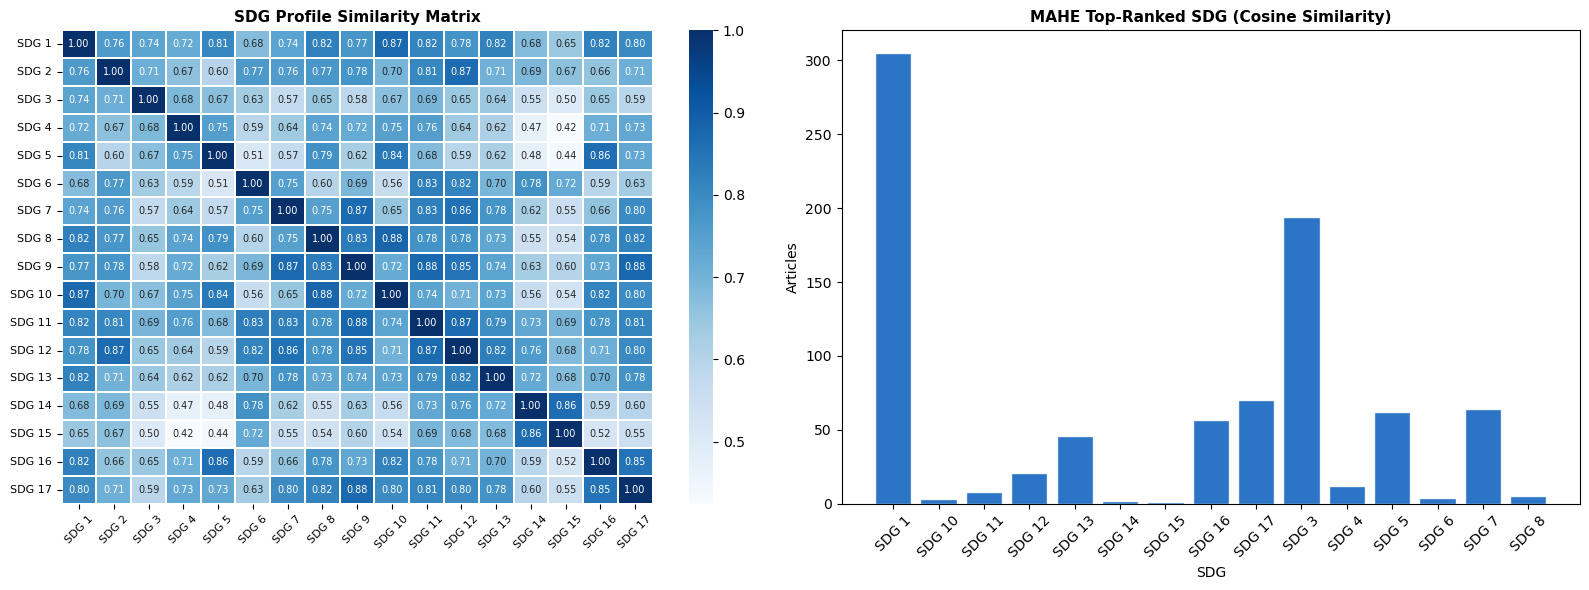

Plot saved


In [10]:
# Cell 10: Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SDG profile similarity heatmap
sns.heatmap(sim_check, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=[f'SDG {s}' for s in sdg_ids],
    yticklabels=[f'SDG {s}' for s in sdg_ids],
    linewidths=0.3, linecolor='white', ax=axes[0], annot_kws={'size':7})
axes[0].set_title('SDG Profile Similarity Matrix', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

# MAHE rank-1 distribution
rank1_dist = df_sim['Rank1_SDG'].value_counts().sort_index()
axes[1].bar(rank1_dist.index, rank1_dist.values, color='#1565C0', edgecolor='white', alpha=0.9)
axes[1].set_title('MAHE Top-Ranked SDG (Cosine Similarity)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('SDG'); axes[1].set_ylabel('Articles')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PLOT_DIR / '10_similarity_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved')


In [11]:
# Cell 11: Combined Track A + Track B ranking
print('Building combined ranking (Track A + Track B)...')
df_tfidf = pd.read_csv(RESULTS_DIR / 'mahe_top5_tfidf.csv')

def parse_all_probs(prob_str, sdg_ids):
    scores = {}
    for part in str(prob_str).split(', '):
        try:
            sdg_part, score = part.rsplit(':', 1)
            sdg_num = int(sdg_part.strip().replace('SDG','').strip())
            scores[sdg_num] = float(score)
        except:
            pass
    return np.array([scores.get(s, 0.0) for s in sdg_ids])

combined_results = []
for i in range(min(len(df_tfidf), len(df_sim))):
    if 'All_Probabilities' in df_tfidf.columns:
        a_scores = parse_all_probs(df_tfidf.iloc[i]['All_Probabilities'], sdg_ids)
    else:
        a_scores = np.zeros(len(sdg_ids))
    a_norm = a_scores / a_scores.sum() if a_scores.sum() > 0 else np.ones(len(sdg_ids)) / len(sdg_ids)
    b_soft = softmax(similarity_matrix[i])
    combined = 0.5 * a_norm + 0.5 * b_soft
    idx = np.argsort(combined)[::-1]
    top5  = [sdg_ids[j] for j in idx[:5]]
    sc5   = [round(float(combined[j]), 4) for j in idx[:5]]
    nm5   = [SDG_NAMES.get(s, '') for s in top5]
    title = df_tfidf.iloc[i]['Title'] if 'Title' in df_tfidf.columns else f'Article {i}'
    combined_results.append({
        'Title':      title,
        'Rank1_SDG':  f'SDG {top5[0]}', 'Rank1_Name': nm5[0], 'Rank1_Score': sc5[0],
        'Rank2_SDG':  f'SDG {top5[1]}', 'Rank2_Name': nm5[1], 'Rank2_Score': sc5[1],
        'Rank3_SDG':  f'SDG {top5[2]}', 'Rank3_Name': nm5[2], 'Rank3_Score': sc5[2],
        'Rank4_SDG':  f'SDG {top5[3]}', 'Rank4_Name': nm5[3], 'Rank4_Score': sc5[3],
        'Rank5_SDG':  f'SDG {top5[4]}', 'Rank5_Name': nm5[4], 'Rank5_Score': sc5[4],
        'Top5_SDGs':  ', '.join([f'SDG {s}' for s in top5]),
        'TrackA_Top1': df_tfidf.iloc[i]['Rank1_SDG'],
        'TrackB_Top1': df_sim.iloc[i]['Rank1_SDG'],
        'Agreement':   df_tfidf.iloc[i]['Rank1_SDG'] == df_sim.iloc[i]['Rank1_SDG'],
    })

df_combined = pd.DataFrame(combined_results)
df_combined.to_csv(RESULTS_DIR / 'mahe_top5_combined.csv', index=False, encoding='utf-8-sig')
agreement_rate = df_combined['Agreement'].mean() * 100
print(f'Saved: data/results/mahe_top5_combined.csv')
print(f'Track A vs Track B agreement on Rank-1: {agreement_rate:.1f}%')
print()
print(df_combined[['Title','Rank1_SDG','Rank1_Name','TrackA_Top1','TrackB_Top1','Agreement']].head(8).to_string())


Building combined ranking (Track A + Track B)...
Saved: data/results/mahe_top5_combined.csv
Track A vs Track B agreement on Rank-1: 30.2%

                                                                                                                                             Title Rank1_SDG                               Rank1_Name TrackA_Top1 TrackB_Top1  Agreement
0                                             Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib     SDG 6               Clean Water and Sanitation       SDG 6       SDG 1      False
1                                                       ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education     SDG 4                        Quality Education       SDG 4       SDG 4       True
2                                             Remote Sensing: A Satellite-Based Advanced Geospatial Technology Boon in Natural Resource Management     SDG 9  Indu

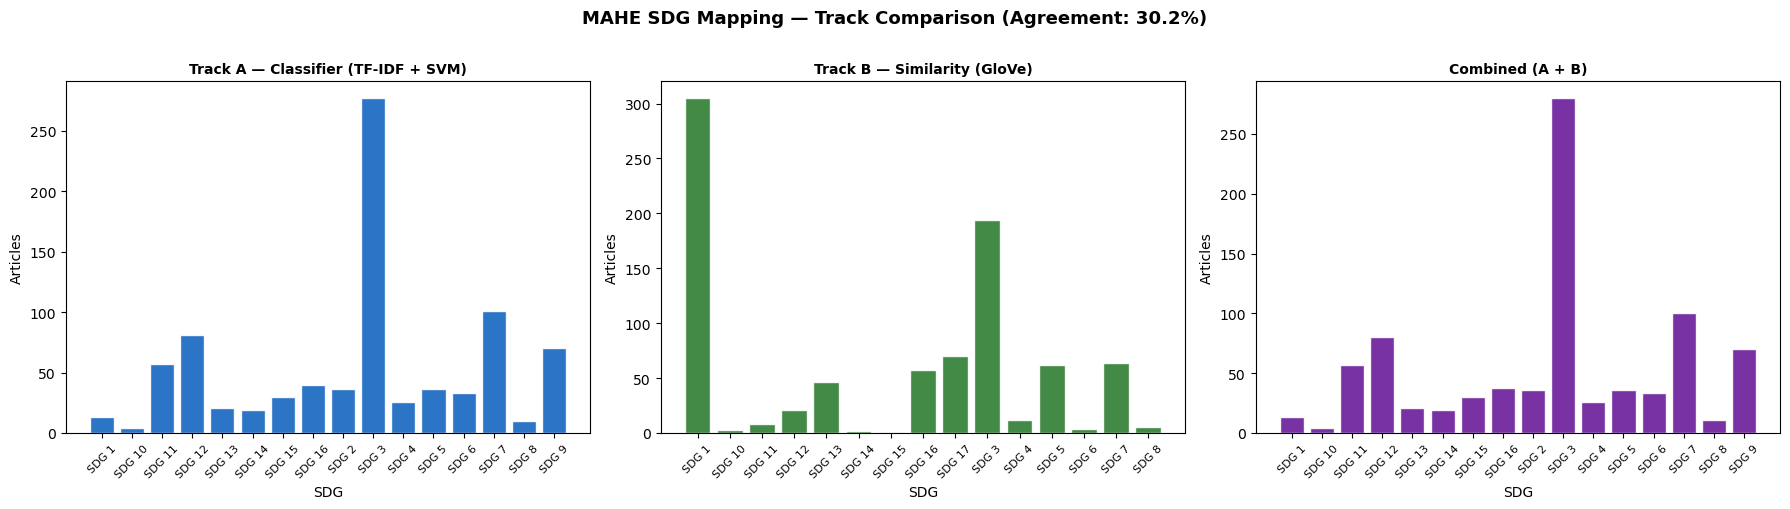

Plot saved


In [12]:
# Cell 12: Track comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color, label in zip(
    axes,
    ['TrackA_Top1', 'TrackB_Top1', 'Rank1_SDG'],
    ['#1565C0', '#2E7D32', '#6A1B9A'],
    ['Track A — Classifier (TF-IDF + SVM)', 'Track B — Similarity (GloVe)', 'Combined (A + B)']
):
    dist = df_combined[col].value_counts().sort_index()
    ax.bar(dist.index, dist.values, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('SDG'); ax.set_ylabel('Articles')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle(f'MAHE SDG Mapping — Track Comparison (Agreement: {agreement_rate:.1f}%)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / '11_track_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved')


In [13]:
# Cell 13: Step 6 summary
print('=' * 62)
print('  STEP 6 - SIMILARITY SCORING SUMMARY')
print('=' * 62)
print()
print('  Method: GloVe cosine similarity + softmax ranking')
print('  SDG profiles: Official UN descriptions for all 17 SDGs')
print('  Note: Covers SDG 17 — missing from OSDG training data')
print()
print(f'  MAHE vectors: {len(mahe_vectors):,} articles (300d GloVe mean pooling)')
print(f'  Coverage    : {(1-zero_count/len(mahe_vectors))*100:.1f}%')
print()
print('  Output files:')
print('    mahe_top5_similarity.csv  — Track B results')
print('    mahe_top5_combined.csv    — Track A + B combined')
print()
print(f'  Track A vs B agreement: {agreement_rate:.1f}%')
if agreement_rate >= 70:
    print('  High agreement — both methods consistently agree on top SDG')
elif agreement_rate >= 50:
    print('  Moderate agreement — methods complement each other well')
else:
    print('  Low agreement — combined ranking is the most robust output')
print()
print('  Key advantage of Track B (direct similarity):')
print('    Maps DIRECTLY to MAHE data without OSDG training')
print('    Covers SDG 17 (missing from OSDG)')
print('    Cosine scores are interpretable and explainable')
print()
print('Step 6 complete -> next: step7_bert.ipynb')
print('=' * 62)


  STEP 6 - SIMILARITY SCORING SUMMARY

  Method: GloVe cosine similarity + softmax ranking
  SDG profiles: Official UN descriptions for all 17 SDGs
  Note: Covers SDG 17 — missing from OSDG training data

  MAHE vectors: 854 articles (300d GloVe mean pooling)
  Coverage    : 100.0%

  Output files:
    mahe_top5_similarity.csv  — Track B results
    mahe_top5_combined.csv    — Track A + B combined

  Track A vs B agreement: 30.2%
  Low agreement — combined ranking is the most robust output

  Key advantage of Track B (direct similarity):
    Maps DIRECTLY to MAHE data without OSDG training
    Covers SDG 17 (missing from OSDG)
    Cosine scores are interpretable and explainable

Step 6 complete -> next: step7_bert.ipynb
